In [35]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
#remove warnings
import warnings
warnings.filterwarnings('ignore')

In [36]:
# Load tips dataset
df = sns.load_dataset('exercise')
df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  90 non-null     int64   
 1   id          90 non-null     int64   
 2   diet        90 non-null     category
 3   pulse       90 non-null     int64   
 4   time        90 non-null     category
 5   kind        90 non-null     category
dtypes: category(3), int64(3)
memory usage: 2.9 KB


In [38]:
# *CRITICAL STEP*: Ensure you handle columns you don't want to use for modeling
# Drop 'Unnamed: 0' and 'id' as they are likely identifiers
df = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')

# 2. Define features (X) and target (y)
# X now only contains the categorical columns you listed
X = df[['diet', 'time', 'kind']]
y = df['pulse'] # Target remains 'pulse'

# 3. Define Categorical Features
categorical_features = ['diet', 'time', 'kind']

# 4. Use ColumnTransformer with only the categorical pipeline
# We use OneHotEncoder to turn text into numbers
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any, which there are none now
)

# 5. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Fit and transform the training data using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)

# 7. Transform the test data using the *same* preprocessor
X_test_processed = preprocessor.transform(X_test)

print("--- Data Preprocessing Complete ---")
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape (now numerical):", X_train_processed.shape)
print("\nData is ready for training a machine learning model.")


--- Data Preprocessing Complete ---
Original X_train shape: (72, 3)
Processed X_train shape (now numerical): (72, 8)

Data is ready for training a machine learning model.


In [ ]:

# Determine the input dimensions for the model
# X_train_processed.shape[1] gives the exact number of features generated by the ColumnTransformer
input_dimensions = X_train_processed.shape[1]

print(f"The model will now expect {input_dimensions} input features.") # Should print 8

# Define your Keras model again with the correct input shape
model = Sequential()
# Update the 'input_dim' or 'input_shape' argument to match the actual data shape
model.add(Dense(10, input_dim=input_dimensions, activation='relu')) 
model.add(Dense(1, activation='linear')) # Output layer for regression (predicting pulse rate)

# Compile the model (assuming regression: mean squared error loss)
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using MAE as an extra metric

early_stopping = EarlyStopping(patience=5)

# Train the model using the correctly shaped data
history = model.fit(
    X_train_processed,  
    y_train,
    epochs=100,
    batch_size=32,
    verbose=1,
    validation_data=(X_test_processed, y_test), 
    callbacks=[early_stopping]
)

# Evaluating the model
loss, mae = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"Test Loss (MSE): {loss}")
print(f"Test Mean Absolute Error (MAE): {mae}")


The model will now expect 8 input features.
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - loss: 10313.7676 - mae: 100.4142 - val_loss: 10165.8975 - val_mae: 99.9791
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 10307.6553 - mae: 100.3836 - val_loss: 10159.5703 - val_mae: 99.9468
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10301.7607 - mae: 100.3537 - val_loss: 10153.3232 - val_mae: 99.9148
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 10295.9180 - mae: 100.3242 - val_loss: 10147.3105 - val_mae: 99.8841
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10290.2617 - mae: 100.2953 - val_loss: 10141.3691 - val_mae: 99.8537
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 10284.5469 - mae: 100.2667 - val_loss: 10135.4141 - val_mae: 99.8232
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10278.8643 - mae: 100.2377 - val_loss: 10129.2812 - val_mae: 99.7918
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 10273.03

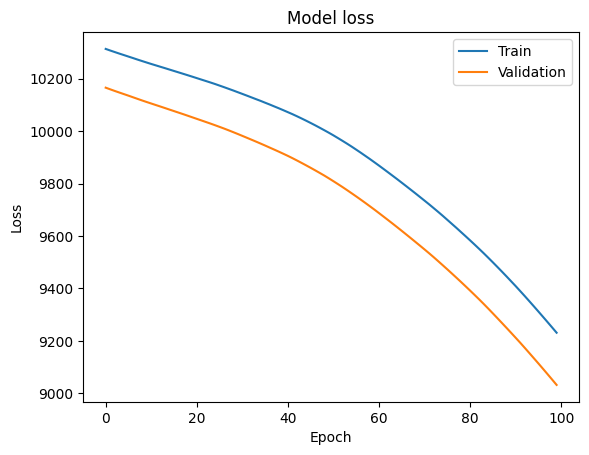

In [40]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()